
# Practical application: a VAR analysis of inflation shocks and Fed rates

This notebook uses the file `Monetary_policy.xlsx` to show, step by step, how to:

1. load and inspect a macroeconomic dataset,
2. identify a Vector Autoregression, or VAR,
3. estimate the model,
4. interpret the main coefficients and diagnostics,
5. study the effect of a one standard deviation inflation shock on the other variables,
6. compare a forecast made at the end of 2021 with what actually happened in 2022.

The variables are:

- **Inflation**
- **Fed Rates**
- **Capacity Utilization Rate**

We keep the code simple and heavily commented so that the logic remains accessible even if you do not come from a mathematical background.



## 1. Economic idea

A VAR treats every variable as potentially influenced by its own past and by the past of the other variables.

In a VAR with \(p\) lags and a vector \(y_t\), the model is:

\begin{align}
y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + \dots + A_p y_{t-p} + u_t
\end{align}

where:

- \(y_t\) is the vector of variables at date \(t\),
- \(c\) is a vector of constants,
- \(A_1, \dots, A_p\) are coefficient matrices,
- \(u_t\) is the vector of unexpected shocks.

In this notebook we define:

\begin{align}
y_t =
\begin{pmatrix}
\text{Inflation}_t \\
\text{Fed Rates}_t \\
\text{Capacity Utilization Rate}_t
\end{pmatrix}
\end{align}

This ordering matters for the shock analysis. By placing inflation first, we assume that a contemporaneous inflation shock can affect the other variables within the same month.


In [1]:

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Time-series econometrics
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

# Make plots a bit cleaner
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True



## 2. Load the data

A very important practical point: the Excel file stores the dates in the first column.

That is why we use:

\begin{align}
\texttt{index\_col = 0}
\end{align}

This tells Python to read the first column as the time index.


In [2]:

# Paths for exports
base_dir = Path("TP5_outputs")
fig_dir = base_dir / "figures"
tab_dir = base_dir / "tables"

base_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)
tab_dir.mkdir(exist_ok=True)

# Load the Excel file
df = pd.read_excel("Monetary_policy.xlsx", index_col=0)

# Convert the index to monthly dates
df.index = pd.to_datetime(df.index)

# Reorder variables for the VAR
df = df[["Inflation", "Fed Rates", "Capacity Utilization Rate"]].dropna()

print(df.head())
print()
print(df.tail())
print()
print(df.info())


            Inflation  Fed Rates  Capacity Utilization Rate
1995-01-31     2.8044       5.53                    84.8472
1995-02-28     2.8630       5.92                    84.4634
1995-03-31     2.8533       5.98                    84.3123
1995-04-30     3.0529       6.05                    83.8748
1995-05-31     3.1864       6.01                    83.9876

            Inflation  Fed Rates  Capacity Utilization Rate
2025-09-30     3.0127       4.22                    76.0745
2025-10-31     2.8739       4.09                    75.6474
2025-11-30     2.7351       3.88                    75.6462
2025-12-31     2.6771       3.72                    75.7433
2026-01-31     2.3864       3.64                    76.2119

<class 'pandas.DataFrame'>
DatetimeIndex: 373 entries, 1995-01-31 to 2026-01-31
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Inflation                  373 non-null    float6


## 3. First look at the data

Before estimating a model, it is always useful to:

- look at the time series,
- compute simple summary statistics,
- check whether the variables move together.

This does not replace econometrics, but it helps us understand the economic story.


In [3]:

def save_table(df_table, filename, title=None, fontsize=9):
    fig, ax = plt.subplots(figsize=(max(8, 2.1 * len(df_table.columns)), max(2, 0.45 * (len(df_table) + 2))))
    ax.axis("off")
    table = ax.table(
        cellText=np.round(df_table.values, 4),
        rowLabels=[str(i) for i in df_table.index],
        colLabels=[str(c) for c in df_table.columns],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.2)
    if title is not None:
        ax.set_title(title, pad=15)
    plt.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close(fig)

# Summary statistics
summary_stats = df.describe().T[["mean", "std", "min", "max"]]
summary_stats.to_csv(tab_dir / "summary_stats.csv")
save_table(summary_stats, tab_dir / "summary_stats.png", "Summary statistics")

# Correlations
correlations = df.corr()
correlations.to_csv(tab_dir / "correlations.csv")
save_table(correlations, tab_dir / "correlations.png", "Correlation matrix")

display(summary_stats)
display(correlations)


,mean,std,min,max
Inflation,2.548053,1.606638,-2.0972,9.0597
Fed Rates,2.555201,2.239489,0.0500,6.5400
Capacity Utilization Rate,77.967795,3.608318,64.0847,84.8918


,Inflation,Fed Rates,Capacity Utilization Rate
Inflation,1.000000,0.240746,0.331292
Fed Rates,0.240746,1.000000,0.670921
Capacity Utilization Rate,0.331292,0.670921,1.000000


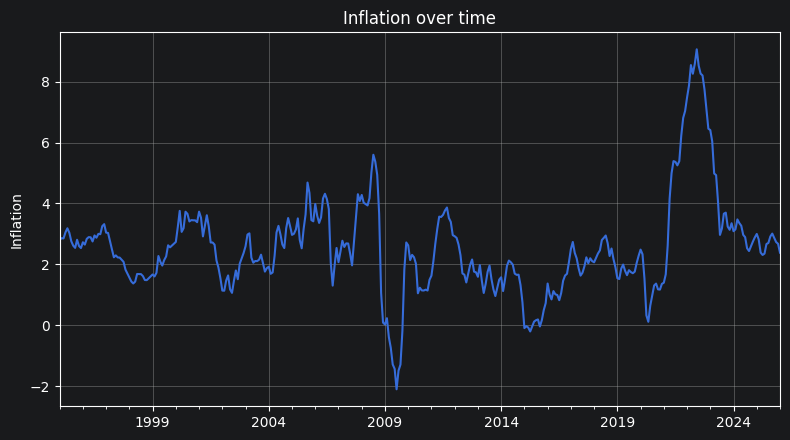

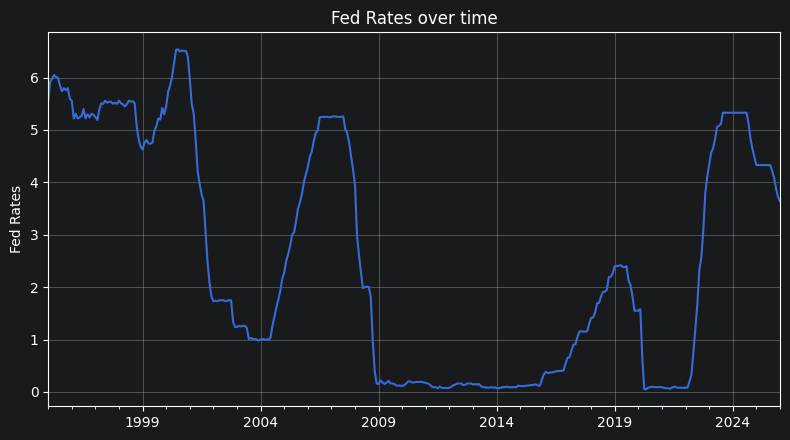

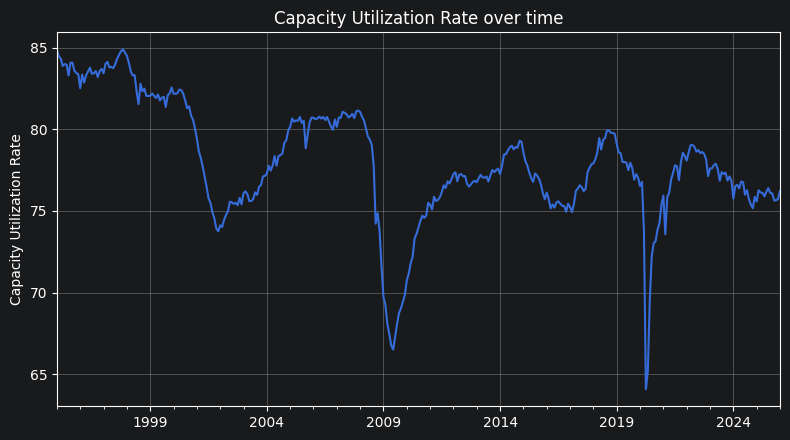

In [4]:

# Plot each series
for column in df.columns:
    fig, ax = plt.subplots()
    df[column].plot(ax=ax)
    ax.set_title(f"{column} over time")
    ax.set_xlabel("")
    ax.set_ylabel(column)
    plt.tight_layout()
    fig.savefig(fig_dir / f"{column.lower().replace(' ', '_')}_history.png", dpi=200)
    plt.show()



## 4. How do we identify the VAR lag length?

A VAR needs a choice for the number of lags \(p\).

If \(p\) is too small, the model may omit useful dynamics.
If \(p\) is too large, the model may become noisy and overfit.

A standard approach is to compare information criteria such as:

- AIC,
- BIC,
- HQIC.

We test lag lengths from 0 to 12 months.


In [5]:

model = VAR(df)
lag_selection = model.select_order(12)

# Put the main criteria into a table
lag_table = pd.DataFrame({
    "AIC": lag_selection.ics["aic"],
    "BIC": lag_selection.ics["bic"],
    "HQIC": lag_selection.ics["hqic"],
    "FPE": lag_selection.ics["fpe"],
})
lag_table.index.name = "Lag"

lag_table.to_csv(tab_dir / "lag_selection.csv")
save_table(lag_table.round(4), tab_dir / "lag_selection.png", "Lag selection criteria", fontsize=8)

print(lag_selection.summary())
display(lag_table.round(4))


C:\Users\rapha\PyCharmMiscProject\Project-IMF\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        4.406       4.439       81.97       4.419
1       -5.888      -5.758    0.002774      -5.836
2       -6.641     -6.415*    0.001306      -6.551
3       -6.720      -6.396    0.001207     -6.591*
4      -6.742*      -6.321   0.001181*      -6.575
5       -6.712      -6.195    0.001216      -6.507
6       -6.718      -6.104    0.001209      -6.474
7       -6.711      -6.000    0.001219      -6.428
8       -6.676      -5.868    0.001262      -6.355
9       -6.659      -5.754    0.001283      -6.300
10      -6.641      -5.639    0.001308      -6.242
11      -6.672      -5.573    0.001268      -6.235
12      -6.645      -5.449    0.001303      -6.170
--------------------------------------------------


,AIC,BIC,HQIC,FPE
Lag,,,,
0,4.4063,4.4386,4.4192,81.9667
1,-5.8876,-5.7583,-5.8362,0.0028
2,-6.6412,-6.4149,-6.5512,0.0013
3,-6.7195,-6.3963,-6.5910,0.0012
4,-6.7416,-6.3215,-6.5746,0.0012
5,-6.7122,-6.1952,-6.5067,0.0012
6,-6.7182,-6.1042,-6.4741,0.0012
7,-6.7105,-5.9995,-6.4278,0.0012
8,-6.6760,-5.8681,-6.3548,0.0013



### Interpretation

In this dataset, the criteria do not all point to the same lag length:

- **BIC** prefers a more parsimonious model,
- **AIC** and **FPE** often accept a richer dynamics.

For teaching purposes, we will estimate a **VAR(4)**. This is economically intuitive with monthly data because it allows the system to remember roughly one quarter of dynamics.



## 5. Estimate the VAR

A VAR(4) writes:

\begin{align}
y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + A_3 y_{t-3} + A_4 y_{t-4} + u_t
\end{align}

Each equation is estimated by ordinary least squares.

This is one of the strengths of the reduced-form VAR: estimation is relatively simple once the lag length is chosen.


In [6]:

var_results = model.fit(4)

print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 31, Mar, 2026
Time:                     12:48:56
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -6.36119
Nobs:                     369.000    HQIC:                  -6.61033
Log likelihood:          -281.865    FPE:                 0.00114261
AIC:                     -6.77452    Det(Omega_mle):      0.00102988
--------------------------------------------------------------------
Results for equation Inflation
                                  coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------------
const                               -0.149069         0.580407           -0.257           0.797
L1.Inflation                         1.425466         0.053724           26.533           0.

In [7]:

# Export two coefficient tables to make the results easier to discuss in class
inflation_eq = pd.DataFrame({
    "coef": var_results.params["Inflation"],
    "std_err": var_results.stderr["Inflation"],
    "t_stat": var_results.tvalues["Inflation"],
    "p_value": var_results.pvalues["Inflation"],
}).round(4)

fed_eq = pd.DataFrame({
    "coef": var_results.params["Fed Rates"],
    "std_err": var_results.stderr["Fed Rates"],
    "t_stat": var_results.tvalues["Fed Rates"],
    "p_value": var_results.pvalues["Fed Rates"],
}).round(4)

inflation_eq.to_csv(tab_dir / "inflation_equation_coefficients.csv")
fed_eq.to_csv(tab_dir / "fed_rate_equation_coefficients.csv")

save_table(inflation_eq, tab_dir / "inflation_equation_coefficients.png", "Inflation equation coefficients", fontsize=8)
save_table(fed_eq, tab_dir / "fed_rate_equation_coefficients.png", "Fed rates equation coefficients", fontsize=8)

display(inflation_eq)
display(fed_eq)


,coef,std_err,t_stat,p_value
const,-0.1491,0.5804,-0.2568,0.7973
L1.Inflation,1.4255,0.0537,26.5332,0.0000
L1.Fed Rates,0.4300,0.1528,2.8150,0.0049
L1.Capacity Utilization Rate,0.0232,0.0275,0.8436,0.3989
L2.Inflation,-0.6530,0.0930,-7.0190,0.0000
L2.Fed Rates,-0.6866,0.2783,-2.4675,0.0136
L2.Capacity Utilization Rate,0.0137,0.0404,0.3388,0.7348
L3.Inflation,0.2490,0.0928,2.6828,0.0073
L3.Fed Rates,-0.0067,0.2852,-0.0233,0.9814
L3.Capacity Utilization Rate,0.0113,0.0393,0.2879,0.7734


,coef,std_err,t_stat,p_value
const,-0.2405,0.2027,-1.1864,0.2355
L1.Inflation,-0.0229,0.0188,-1.2187,0.2230
L1.Fed Rates,1.5461,0.0533,28.9819,0.0000
L1.Capacity Utilization Rate,0.0141,0.0096,1.4747,0.1403
L2.Inflation,0.0493,0.0325,1.5184,0.1289
L2.Fed Rates,-0.5358,0.0972,-5.5137,0.0000
L2.Capacity Utilization Rate,-0.0231,0.0141,-1.6417,0.1007
L3.Inflation,-0.0682,0.0324,-2.1043,0.0354
L3.Fed Rates,0.1035,0.0996,1.0390,0.2988
L3.Capacity Utilization Rate,0.0247,0.0137,1.8002,0.0718



## 6. Simple diagnostics

Two useful checks are:

1. **stability** of the VAR,
2. **residual autocorrelation**.

### Stability

A stable VAR has impulse responses that eventually die out.
In `statsmodels`, a stable VAR is indicated by roots whose modulus is larger than 1.

### Residual autocorrelation

If residuals still contain a lot of serial dependence, the model may be missing some dynamics.


In [8]:

# Stability
roots = var_results.roots
stability_table = pd.DataFrame({
    "root_real": np.real(roots),
    "root_imag": np.imag(roots),
    "modulus": np.abs(roots),
}).round(4)

stability_table.to_csv(tab_dir / "stability_roots.csv", index=False)
save_table(stability_table.head(12), tab_dir / "stability_roots.png", "Roots of the VAR", fontsize=8)

is_stable = np.all(np.abs(roots) > 1)
print(f"Is the VAR stable? {is_stable}")

# Residual Ljung-Box test at 12 lags
lb_output = {}
for variable in var_results.resid.columns:
    lb_output[variable] = acorr_ljungbox(var_results.resid[variable], lags=[12], return_df=True)

lb_table = pd.concat(lb_output, axis=0)
lb_table.to_csv(tab_dir / "ljung_box.csv")
print(lb_table)


Is the VAR stable? True
                                lb_stat     lb_pvalue
Inflation                 12  97.812278  1.491885e-15
Fed Rates                 12  11.839427  4.586602e-01
Capacity Utilization Rate 12   9.468109  6.625126e-01



### Diagnostic reading

- If the VAR is stable, shock responses can be interpreted in the usual way.
- If residual autocorrelation remains strong in one equation, that is a sign that the model is useful but not perfect.

That is normal in macroeconomics: even reasonable models do not capture everything.



## 7. Impulse response analysis

Now we study the effect of a **one standard deviation inflation shock**.

In reduced-form VAR work, this is usually done with an orthogonalized impulse response. The idea is:

\begin{align}
u_t = P \varepsilon_t
\end{align}

where \(P\) is a matrix such that:

\begin{align}
\Sigma_u = P P'
\end{align}

and \(\varepsilon_t\) contains orthogonal shocks.

Because we ordered inflation first, the inflation shock is identified as the first orthogonalized innovation.


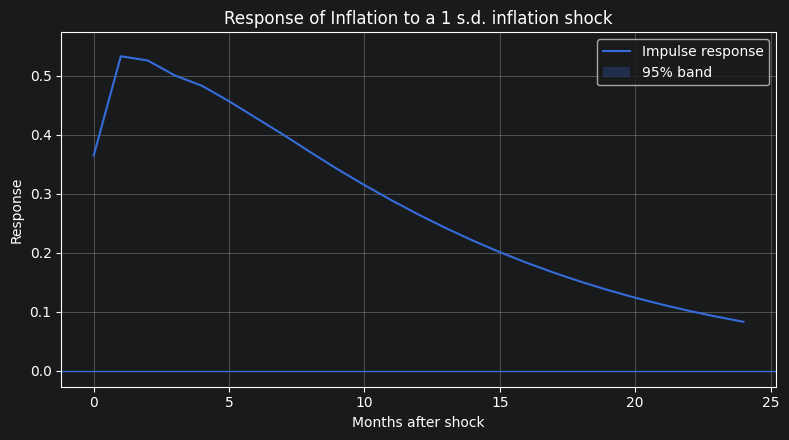

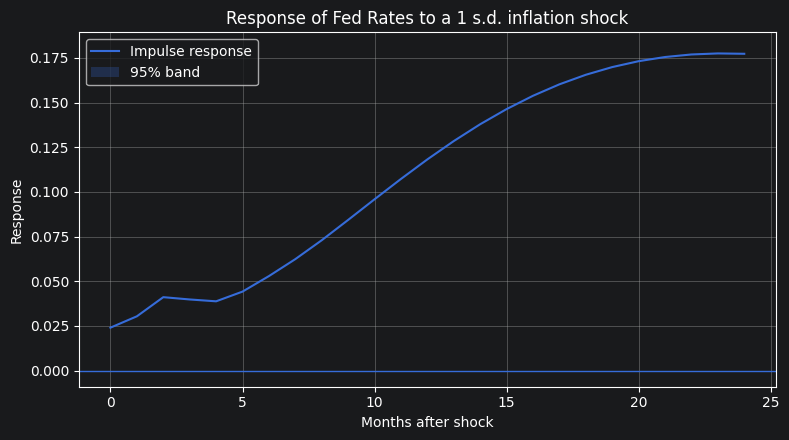

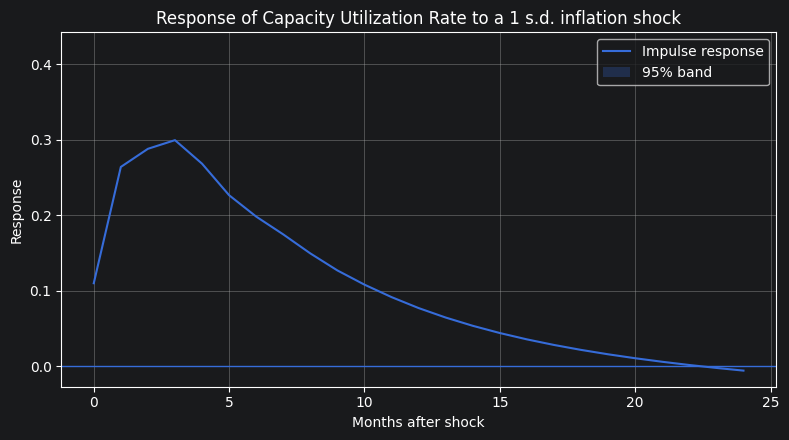

In [9]:

irf = var_results.irf(24)

# Confidence bands from Monte Carlo simulation
lower_band, upper_band = irf.errband_mc(orth=True, repl=300, signif=0.05, seed=42)

variables = df.columns.tolist()
impulse_name = "Inflation"
impulse_index = variables.index(impulse_name)

for response_name in variables:
    response_index = variables.index(response_name)

    response_values = irf.orth_irfs[:, response_index, impulse_index]
    lower_values = lower_band[:, response_index, impulse_index]
    upper_values = upper_band[:, response_index, impulse_index]

    fig, ax = plt.subplots()
    horizons = np.arange(len(response_values))

    ax.plot(horizons, response_values, label="Impulse response")
    ax.fill_between(horizons, lower_values, upper_values, alpha=0.25, label="95% band")
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Response of {response_name} to a 1 s.d. inflation shock")
    ax.set_xlabel("Months after shock")
    ax.set_ylabel("Response")
    ax.legend()
    plt.tight_layout()

    filename = fig_dir / f"irf_{response_name.lower().replace(' ', '_')}_to_inflation.png"
    fig.savefig(filename, dpi=200)
    plt.show()



## 8. How do we read the shock analysis?

For each variable, ask three questions:

1. **Sign** - does the variable go up or down after the inflation shock?
2. **Size** - is the response economically large or small?
3. **Persistence** - does the effect disappear quickly, or does it stay for many months?

In a standard monetary policy interpretation, we expect:

- inflation to react positively on impact,
- Fed rates to move up with a delay if the central bank responds,
- real activity proxies, such as capacity utilization, to weaken later if tighter policy slows the economy.

The exact pattern in the data is what the VAR is meant to reveal.



## 9. Forecast experiment: what did a VAR know at the end of 2021?

We now simulate the perspective of an economist standing in **December 2021**.

We estimate the VAR only on data available up to the end of 2021, then forecast the 12 months of 2022.

This is useful because 2022 was a year of unusually strong inflation pressure. The comparison between forecast and realization helps students see what happens when a model faces a large shock that is not already embedded in the historical dynamics.


In [10]:

# Split the sample
train = df.loc[: "2021-12-31"]
test = df.loc["2022-01-31":"2022-12-31"]

# Re-estimate the VAR on the training sample only
var_train = VAR(train).fit(4)

# Forecast 12 months ahead
forecast_values = var_train.forecast(train.values[-4:], steps=len(test))
forecast_df = pd.DataFrame(forecast_values, index=test.index, columns=df.columns)

# Forecast errors and RMSE
forecast_errors = test - forecast_df
rmse = pd.DataFrame(np.sqrt((forecast_errors ** 2).mean()), columns=["RMSE"])

rmse.to_csv(tab_dir / "forecast_rmse_2022.csv")
save_table(rmse, tab_dir / "forecast_rmse_2022.png", "2022 forecast RMSE")

display(rmse)
display(forecast_df.head())


C:\Users\rapha\PyCharmMiscProject\Project-IMF\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


,RMSE
Inflation,3.479024
Fed Rates,2.351208
Capacity Utilization Rate,1.806162


,Inflation,Fed Rates,Capacity Utilization Rate
2022-01-31,6.829801,0.038362,78.257672
2022-02-28,6.393173,-0.012440,78.037847
2022-03-31,5.906981,-0.070462,77.717187
2022-04-30,5.456443,-0.120369,77.356920
2022-05-31,5.050458,-0.157778,77.039491


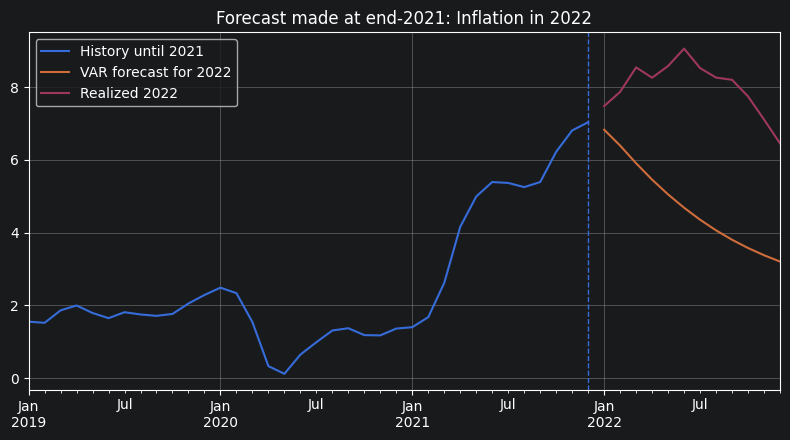

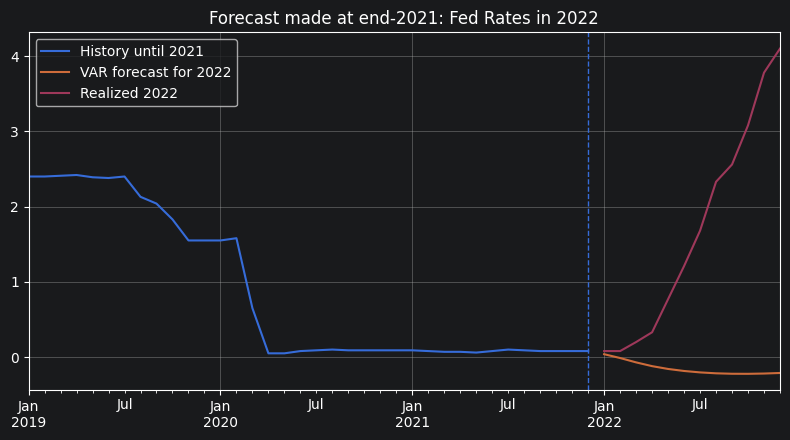

In [11]:

# Plot forecast versus realized values for inflation and Fed rates
for variable in ["Inflation", "Fed Rates"]:
    fig, ax = plt.subplots()

    train[variable].loc["2019-01-31":].plot(ax=ax, label="History until 2021")
    forecast_df[variable].plot(ax=ax, label="VAR forecast for 2022")
    test[variable].plot(ax=ax, label="Realized 2022")

    ax.axvline(pd.Timestamp("2021-12-31"), linestyle="--", linewidth=1)
    ax.set_title(f"Forecast made at end-2021: {variable} in 2022")
    ax.set_xlabel("")
    ax.legend()
    plt.tight_layout()

    filename = fig_dir / f"forecast_vs_realized_{variable.lower().replace(' ', '_')}_2022.png"
    fig.savefig(filename, dpi=200)
    plt.show()


In [12]:

comparison_table = pd.DataFrame({
    "Forecast average in 2022": [forecast_df["Inflation"].mean(), forecast_df["Fed Rates"].mean()],
    "Realized average in 2022": [test["Inflation"].mean(), test["Fed Rates"].mean()],
}, index=["Inflation", "Fed Rates"])

comparison_table["Forecast error"] = comparison_table["Realized average in 2022"] - comparison_table["Forecast average in 2022"]

comparison_table.to_csv(tab_dir / "forecast_comparison_2022.csv")
save_table(comparison_table, tab_dir / "forecast_comparison_2022.png", "Forecast vs realized averages in 2022")

display(comparison_table.round(4))


,Forecast average in 2022,Realized average in 2022,Forecast error
Inflation,4.7253,8.0077,3.2824
Fed Rates,-0.1500,1.6833,1.8333



## 10. What do we learn from the 2022 forecast miss?

If the realized inflation path in 2022 is much higher than the model forecast made in late 2021, the lesson is clear:

\begin{align}
\text{Realized inflation in 2022} \; > \; \text{VAR forecast made at end-2021}
\end{align}

This means that the economy was hit by unusually large inflationary forces relative to what the historical sample suggested.

If realized Fed rates are also above the forecast, it shows the monetary policy reaction to that inflation surprise.

This is exactly why forecasting exercises are pedagogically useful:

- they reveal what the model had learned from history,
- they show when history is not enough,
- they illustrate how a shock can propagate through inflation and policy rates.



## 11. Main conclusions for students

This practical application illustrates four core ideas.

### 1. A VAR is a system
Inflation, policy rates, and activity indicators should not be studied in isolation.

### 2. Identification matters
The variable ordering matters in orthogonalized impulse responses.

### 3. Estimation is easy, interpretation is harder
The software estimates the VAR quickly, but economic judgment is still needed to choose:
- the variables,
- the lag length,
- the identification strategy.

### 4. Forecast errors are informative
The failure of the end-2021 forecast to fully anticipate 2022 is not just a mistake.
It is evidence that the economy experienced an inflation shock outside normal historical patterns.


In [13]:

# Save the cleaned dataset used in the notebook
df.to_csv(base_dir / "monetary_policy_clean.csv")

print("All charts and tables have been exported to:")
print(base_dir.resolve())


All charts and tables have been exported to:
C:\Users\rapha\PyCharmMiscProject\Project-IMF\Class exercice\var_monetary_policy
